# T69 -- Devonian paleogeography and climatology

**Cluster J: Paleoclimate.**  *Datasets:* Scotese & Wright (2018) paleogeography, reconstructed live with `gplately`; Pohl's FOAM ocean-atmosphere GCM climatology (Pohl, A. -- Zenodo archive, CC BY 4.0), the actual GCM run that built the boundary condition for cGENIE's Devonian/Carboniferous ocean-oxygenation experiments.

Two published cGENIE studies -- Pohl et al. (2022, *Nature*) and G&eacute;rard et al. (2025, *Climate of the Past*) -- ran a series of Devonian-Carboniferous continental configurations (cGENIE's `Scot360M` ... `Scot420M` config family, 360-420 Ma) to test whether *continental configuration itself*, independent of atmospheric CO2, was a first-order control on ocean oxygenation through this interval. Their own model repository documents the source plainly: *"All Devonian continental configuration from Scotese and Wright (2018)"* (`Gerard_et_al_2024/readme.txt`).

**What this notebook can and cannot show.** None of these two papers archived their finished cGENIE ocean-oxygen output as open data -- only the model code and configuration files are published (Zenodo: 10.5281/zenodo.6823664, 10.5281/zenodo.14680971). Reproducing their O2 maps would mean actually compiling and running cGENIE, which is out of scope here. What *is* openly archived, and is not a substitute but the literal upstream input, is the FOAM GCM climatology cGENIE's own `muffingen` tool converts into each `Scot*` boundary condition -- real physical fields (temperature, winds, ocean currents) on the real Scotese & Wright (2018) continental configuration, at the same ages. This notebook reconstructs the paleogeography and renders that real climatology, rather than presenting invented or approximated ocean-oxygenation numbers.

## What this notebook produces

1. **&sect;2 -- Reconstructing Devonian paleogeography.** `gplately` + Scotese & Wright (2018) coastlines and continents at the two ends of the FOAM archive's Devonian coverage: 420 Ma (Early Devonian) and 360 Ma (the Devonian-Carboniferous boundary, coincident with the end-Devonian Hangenberg extinction).
2. **&sect;3 -- Surface climatology at each age.** FOAM's own surface air temperature and near-surface winds, on the reconstructed paleogeography.
3. **&sect;4 -- Ocean surface temperature and circulation.** FOAM's ocean-component SST and surface currents -- the field most directly relevant to the papers' oxygenation argument, since ocean circulation reorganisation is their proposed mechanism.
4. **&sect;5 -- Quantifying the 60 Myr change.** A simple, direct diagnostic: how much does global-mean and equator-to-pole SST contrast change between 420 and 360 Ma, on these two real continental configurations?

## Learning objectives

- Reconstruct a deep-time paleogeography with `gplately` at a specific published-model age, and understand why this is the same source cGENIE's own Devonian boundary conditions use (`Scot360M`-`Scot420M`, generated directly from Scotese's topography files via `muffingen` -- confirmed in the model repository).
- Distinguish between a model's finished, published *output* (not archived here) and its openly-archived *input/boundary condition* (is archived) -- and be explicit about which one a notebook is actually showing.
- Render multi-level atmosphere and ocean GCM NetCDF output (monthly climatology, pressure/depth levels) as `pygmt` maps on a `gplately`-reconstructed deep-time coastline.
- Compute a simple, honest quantitative comparison across two reconstructed ages, rather than asserting a causal claim (oxygenation) the available data cannot support.

## Prerequisites and runtime

- **Plate model**: Scotese & Wright (2018) -- the exact, documented source of cGENIE's own `Scot*` Devonian configuration family.
- **Data**: `zenodo_data/foam_devonian_climatology_Pohl/` (601 MB, not bundled in git -- see `zenodo_data/README.md`). Pohl, A. -- *Phanerozoic global climatic fields simulated using the FOAM ocean-atmosphere general circulation model*. Zenodo. https://doi.org/10.5281/zenodo.5780097 (CC BY 4.0). Plus two Scotese & Wright (2018) PaleoDEM grids (420 Ma, 360 Ma) from `zenodo_data/paleoDEM_ScoteseWright2018/`.
- **Python**: `gplately`, `pygmt`, `pygplates`, `plate_model_manager`, `xarray`, `numpy`, `pandas`.
- **Runtime**: ~40 s.


## Environment + imports

In [1]:
from pathlib import Path
import os, sys
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import xarray as xr
import pygmt
import gplately
import pygplates
from plate_model_manager import PlateModelManager

sys.path.insert(0, str(Path("Notebooks").resolve()))
from data_check import require_data
from paleoclimate_helpers import refine_for_plot
require_data(["zenodo_data/foam_devonian_climatology_Pohl/", "zenodo_data/paleoDEM_ScoteseWright2018/"])

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, xr, pygmt, gplately, pygplates):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', getattr(_m, 'version', 'n/a'))}")


Environment
  python      3.12.5
  numpy       2.3.2
  pandas      2.2.3
  xarray      2026.4.0
  pygmt       v0.18.0
  gplately    2.0.0.post19+git.2cce7bb3
  pygplates   1.0.0


## Configuration

In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME = "scotese_and_wright2018"   # the exact source of cGENIE's Scot360M-Scot420M configs
AGES       = [420.0, 360.0]              # Early Devonian -> Devonian-Carboniferous (Hangenberg) boundary
AGE_LABELS = {420.0: "420 Ma (Early Devonian)", 360.0: "360 Ma (Devonian-Carboniferous boundary)"}

DATA_DIR     = Path("zenodo_data/foam_devonian_climatology_Pohl")
PALEODEM_DIR = Path("zenodo_data/paleoDEM_ScoteseWright2018")   # Scotese & Wright (2018) elevation grids

REGION = "d"
PROJ   = "N16c"

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


## 1. Load the FOAM climatology

Each age has two NetCDF files: `atmos` (18 pressure levels, 40x48 lat/lon, 12-month climatology) and `ocean` (24 depth levels, 128x128 grid, 12-month climatology). `decode_times=False` is needed -- the files use a "days since year 0" calendar that neither `pandas` nor `cftime` can represent, and the actual dates are irrelevant here (this is a repeating climatology, not a real calendar).

In [3]:
foam = {}
for age in AGES:
    age_int = int(age)
    foam[age] = {
        "atmos": xr.open_dataset(DATA_DIR / f"{age_int}rd_1368W_EccN_atmos_2240ppm.nc", decode_times=False),
        "ocean": xr.open_dataset(DATA_DIR / f"{age_int}rd_1368W_EccN_ocean_2240ppm.nc", decode_times=False),
    }
    a, o = foam[age]["atmos"], foam[age]["ocean"]
    print(f"  {AGE_LABELS[age]}: atmos {dict(a.sizes)}, ocean {dict(o.sizes)}")


  420 Ma (Early Devonian): atmos {'ilev': 19, 'lev': 18, 'lat': 40, 'time': 12, 'lon': 48}, ocean {'time': 12, 'lev': 24, 'lat': 128, 'lon': 128}
  360 Ma (Devonian-Carboniferous boundary): atmos {'ilev': 19, 'lev': 18, 'lat': 40, 'time': 12, 'lon': 48}, ocean {'time': 12, 'lev': 24, 'lat': 128, 'lon': 128}


## 2. Reconstructing Devonian paleogeography

The same `gplately` pattern used throughout this suite -- but here the reconstructed age is not a free choice: it has to match a FOAM archive age exactly, because the paleogeography *is* the boundary condition the climatology was run on, not just a map decoration.

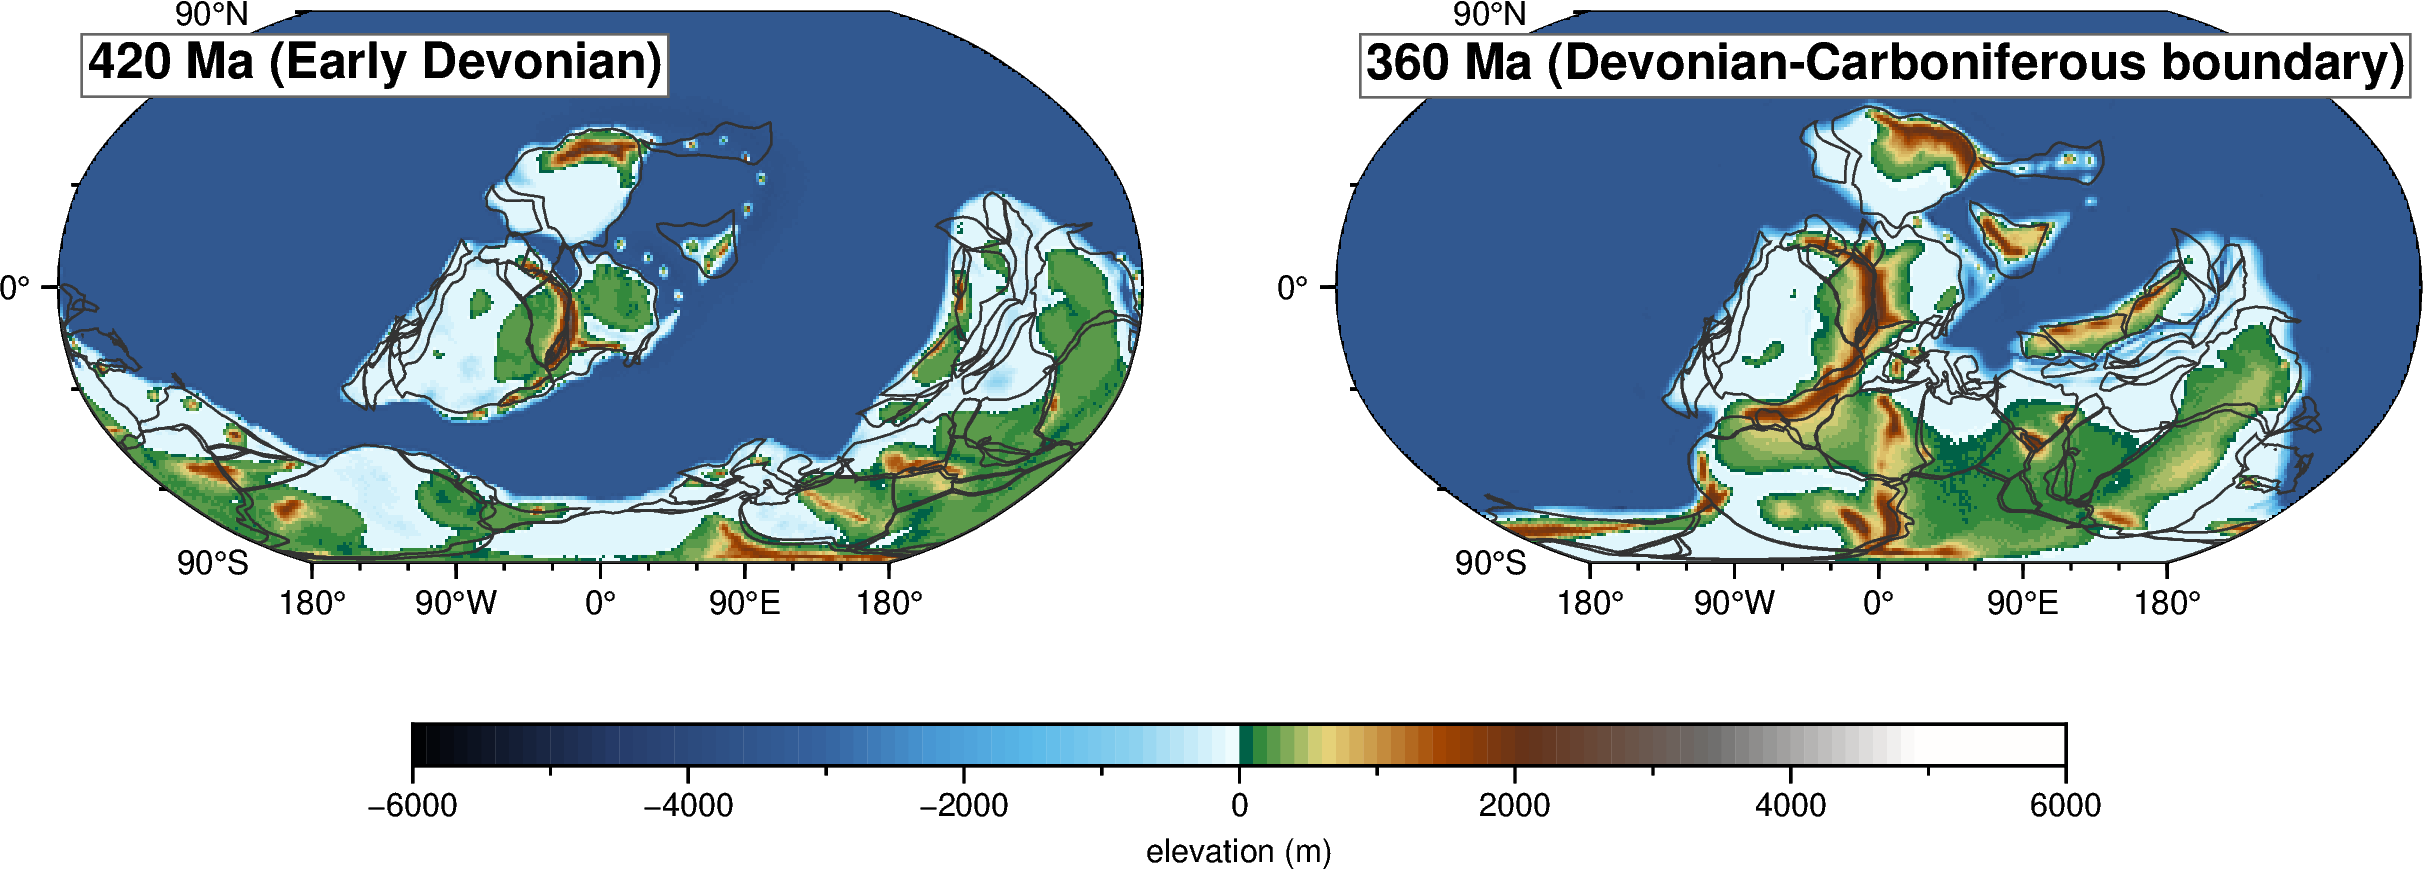

In [4]:
def load_paleodem(age):
    """Locate the Scotese & Wright (2018) PaleoDEM grid nearest to `age` (Ma).
    Globs for any file ending in '_<int_age>Ma.nc' -- matches the published
    `Map##_PALEOMAP_*deg_*_<age>Ma.nc` naming convention (T47 uses the same pattern)."""
    hits = sorted(PALEODEM_DIR.glob(f"*_{int(round(age))}Ma.nc"))
    if not hits:
        raise FileNotFoundError(f"No PaleoDEM at {age} Ma under {PALEODEM_DIR}")
    return xr.open_dataset(hits[0])["z"]

pmm = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="data/pmm_cache")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)

gm = {}
elev = {}
for age in AGES:
    gm[age] = gplately.PlotTopologies(
        plate_reconstruction=recon,
        continents=model.get_continental_polygons(),
        COBs=model.get_COBs(),
        time=float(age),
        plot_engine=gplately.PygmtPlotEngine(),
    )
    elev[age] = load_paleodem(age)

fig = pygmt.Figure()
pygmt.makecpt(cmap="geo", series=[-6000, 6000, 100], background="o")
with fig.subplot(nrows=1, ncols=2, figsize=("20c", "5.8c"), margins=["0.6c", "0.4c"]):
    for i, age in enumerate(AGES):
        with fig.set_panel(panel=i):
            fig.basemap(region=REGION, projection="N?", frame="af")
            fig.grdimage(grid=elev[age], nan_transparent=True)
            gm[age].plot_continents(fig, fill=None, pen="0.5p,gray20")
            fig.text(text=AGE_LABELS[age], position="TL", offset="0.25c/-0.25c", justify="TL",
                      font="12p,Helvetica-Bold,black", fill="white", pen="0.5p,gray40")
fig.colorbar(frame="af+lelevation (m)", position="JBC+w14c/0.35c+h+o0/0.8c")
fig.savefig(OUTPUT_DIR / "T69_devonian_paleogeography.png", dpi=150)
fig.show(width=1000)


**What this shows.** Across the 60 Myr spanned by these two snapshots, the supercontinent Euramerica/Laurussia (fused Laurentia + Baltica + Avalonia by this point) sits astride the palaeo-equator in both, with Gondwana occupying the southern high latitudes -- the broad "Old Red Sandstone continent" configuration typical of the Devonian. The main visible change is the continued northward drift and narrowing of the Rheic Ocean separating Gondwana from Laurussia, part of the long convergence that eventually assembles Pangaea in the Carboniferous-Permian. This is the actual paleogeography Pohl et al. and G&eacute;rard et al.'s `Scot360M`-`Scot420M` cGENIE configs were built on -- not an approximation of it. The colour fill is the actual Scotese & Wright (2018) elevation model (land and submerged crust alike, -6000 to +6000 m), not a flat continent mask -- the same field `muffingen` samples to build cGENIE's land-sea mask and runoff routing, so the topographic detail visible here (highlands, epicontinental seas) is directly relevant to the boundary condition, not just decoration.

## 3. Surface climatology at each age

FOAM's own near-surface air temperature (`TS1`) and lowest-level winds (`U`, `V` at `lev` index closest to the surface), averaged over the 12-month climatology.

grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.
grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


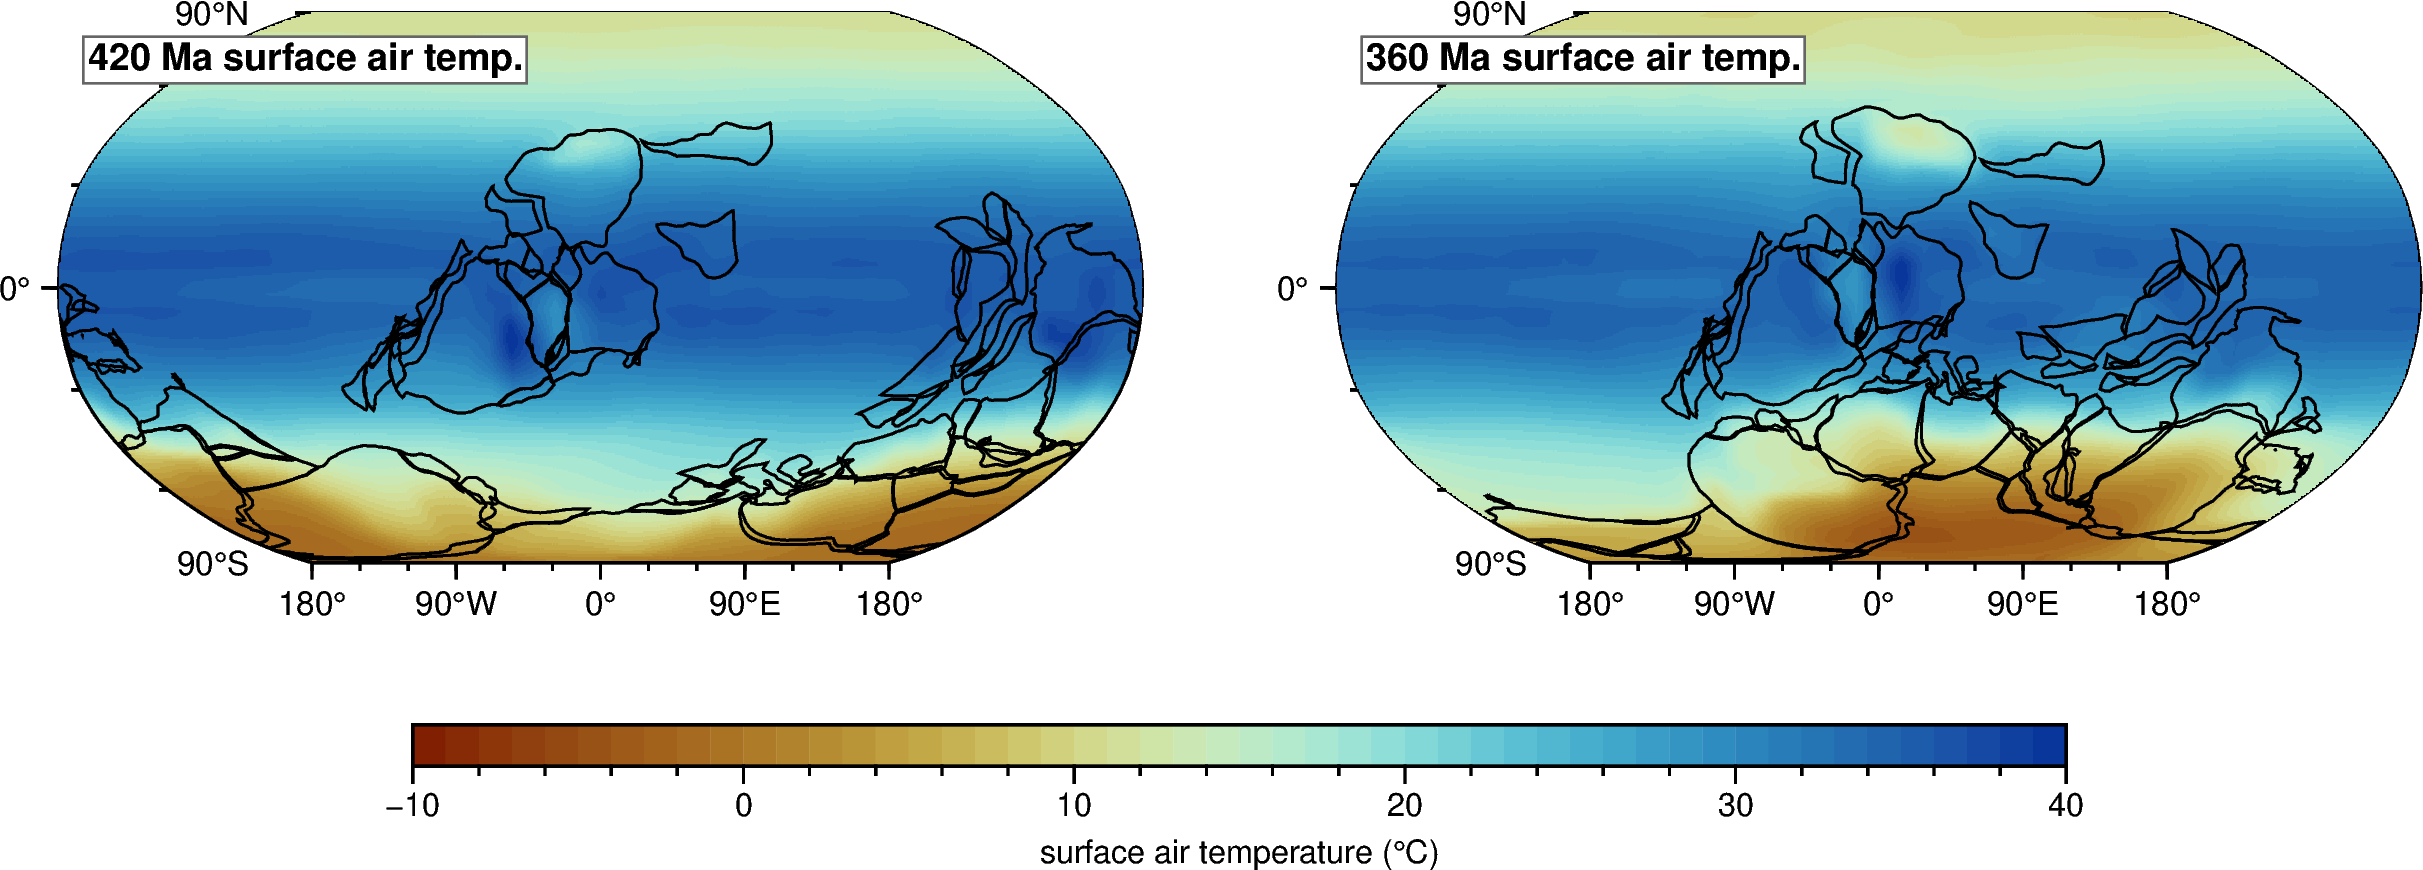

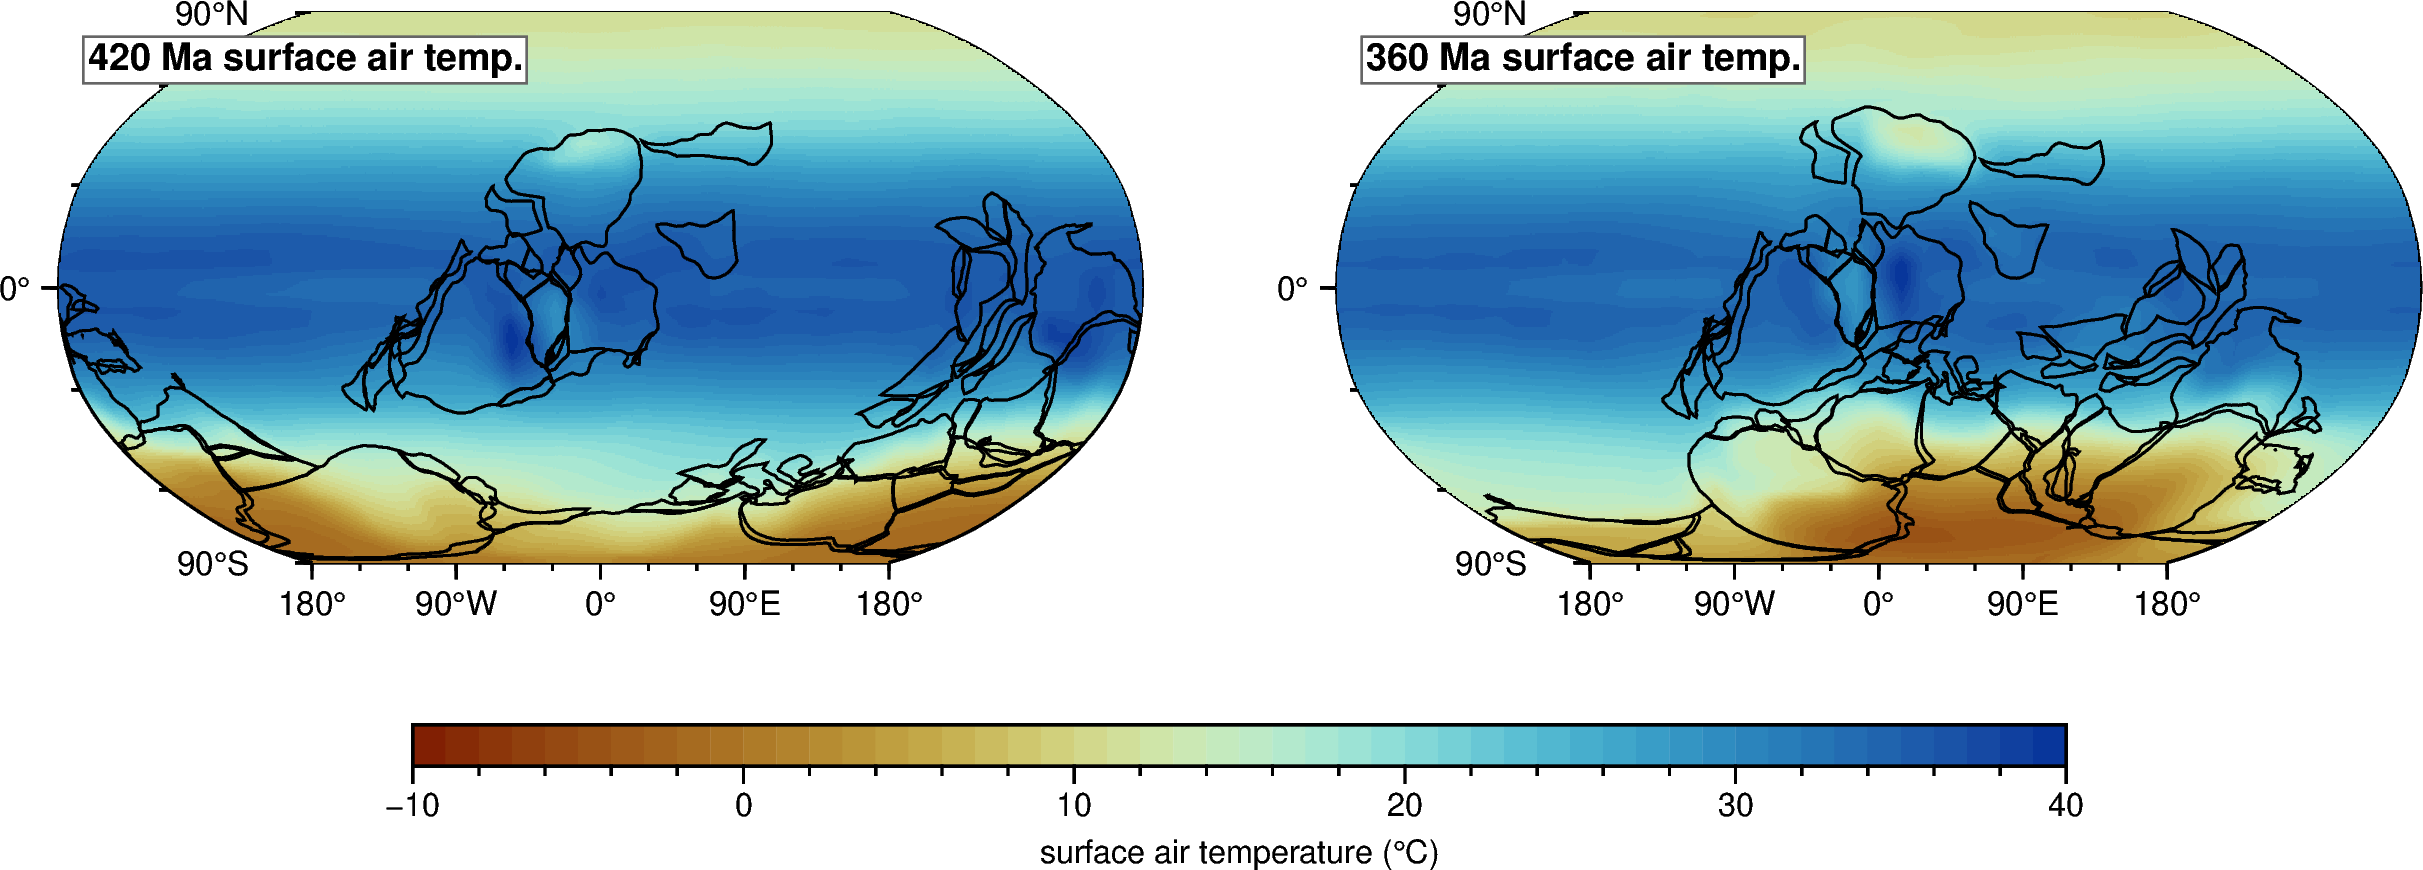

In [5]:
fig = pygmt.Figure()
pygmt.makecpt(cmap="roma", series=[-10, 40, 1], background="o")
with fig.subplot(nrows=1, ncols=2, figsize=("20c", "5.8c"), margins=["0.6c", "0.4c"]):
    for i, age in enumerate(AGES):
        atmos = foam[age]["atmos"]
        ts = (atmos["TS1"].mean(dim="time") - 273.15)  # K -> degC
        ts_plot = refine_for_plot(ts.assign_coords(lon=(((atmos.lon + 180) % 360) - 180)).sortby("lon"))
        with fig.set_panel(panel=i):
            fig.basemap(region=REGION, projection="N?", frame="af")
            fig.grdimage(grid=ts_plot, nan_transparent=True)
            gm[age].plot_continents(fig, fill=None, pen="0.6p,black")
            fig.text(text=f"{age:.0f} Ma surface air temp.", position="TL", offset="0.25c/-0.25c",
                      justify="TL", font="9p,Helvetica-Bold,black", fill="white", pen="0.5p,gray40")
fig.colorbar(frame="af+lsurface air temperature (\u00b0C)", position="JBC+w14c/0.35c+h+o0/0.8c")
fig.savefig(OUTPUT_DIR / "T69_surface_air_temperature.png", dpi=150)
fig.show(width=1000)


**What this shows.** Both Devonian climatologies are warm, ice-free worlds by construction (FOAM's boundary conditions here use a fixed, elevated CO2 forcing common to the whole Pohl et al. sensitivity-experiment series -- see the papers' own remark that "these continental configurations are not intended...to conduct 'realistic' simulations" of absolute temperature, only relative sensitivity to geography). The broad pattern -- warm, relatively flat low-to-mid-latitude temperatures with cooling toward the poles -- is consistent between the two ages; continental interior locations (Laurussia, interior Gondwana) run warmer than adjacent open ocean at the same latitude in both, the expected land-sea contrast from continentality alone.

## 4. Ocean surface temperature and circulation

This is the field the papers' mechanism actually concerns: ocean circulation reorganisation as continents drift, changing upwelling, gyre strength, and hence nutrient supply and productivity -- the chain of causation Pohl et al. (2022) and Gerard et al. (2024) propose links continental configuration to ocean oxygenation. `TEMP` at the shallowest ocean level (index -1, nominal depth 10 m) plus surface currents (`U`, `V` at the same level).

grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.
grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


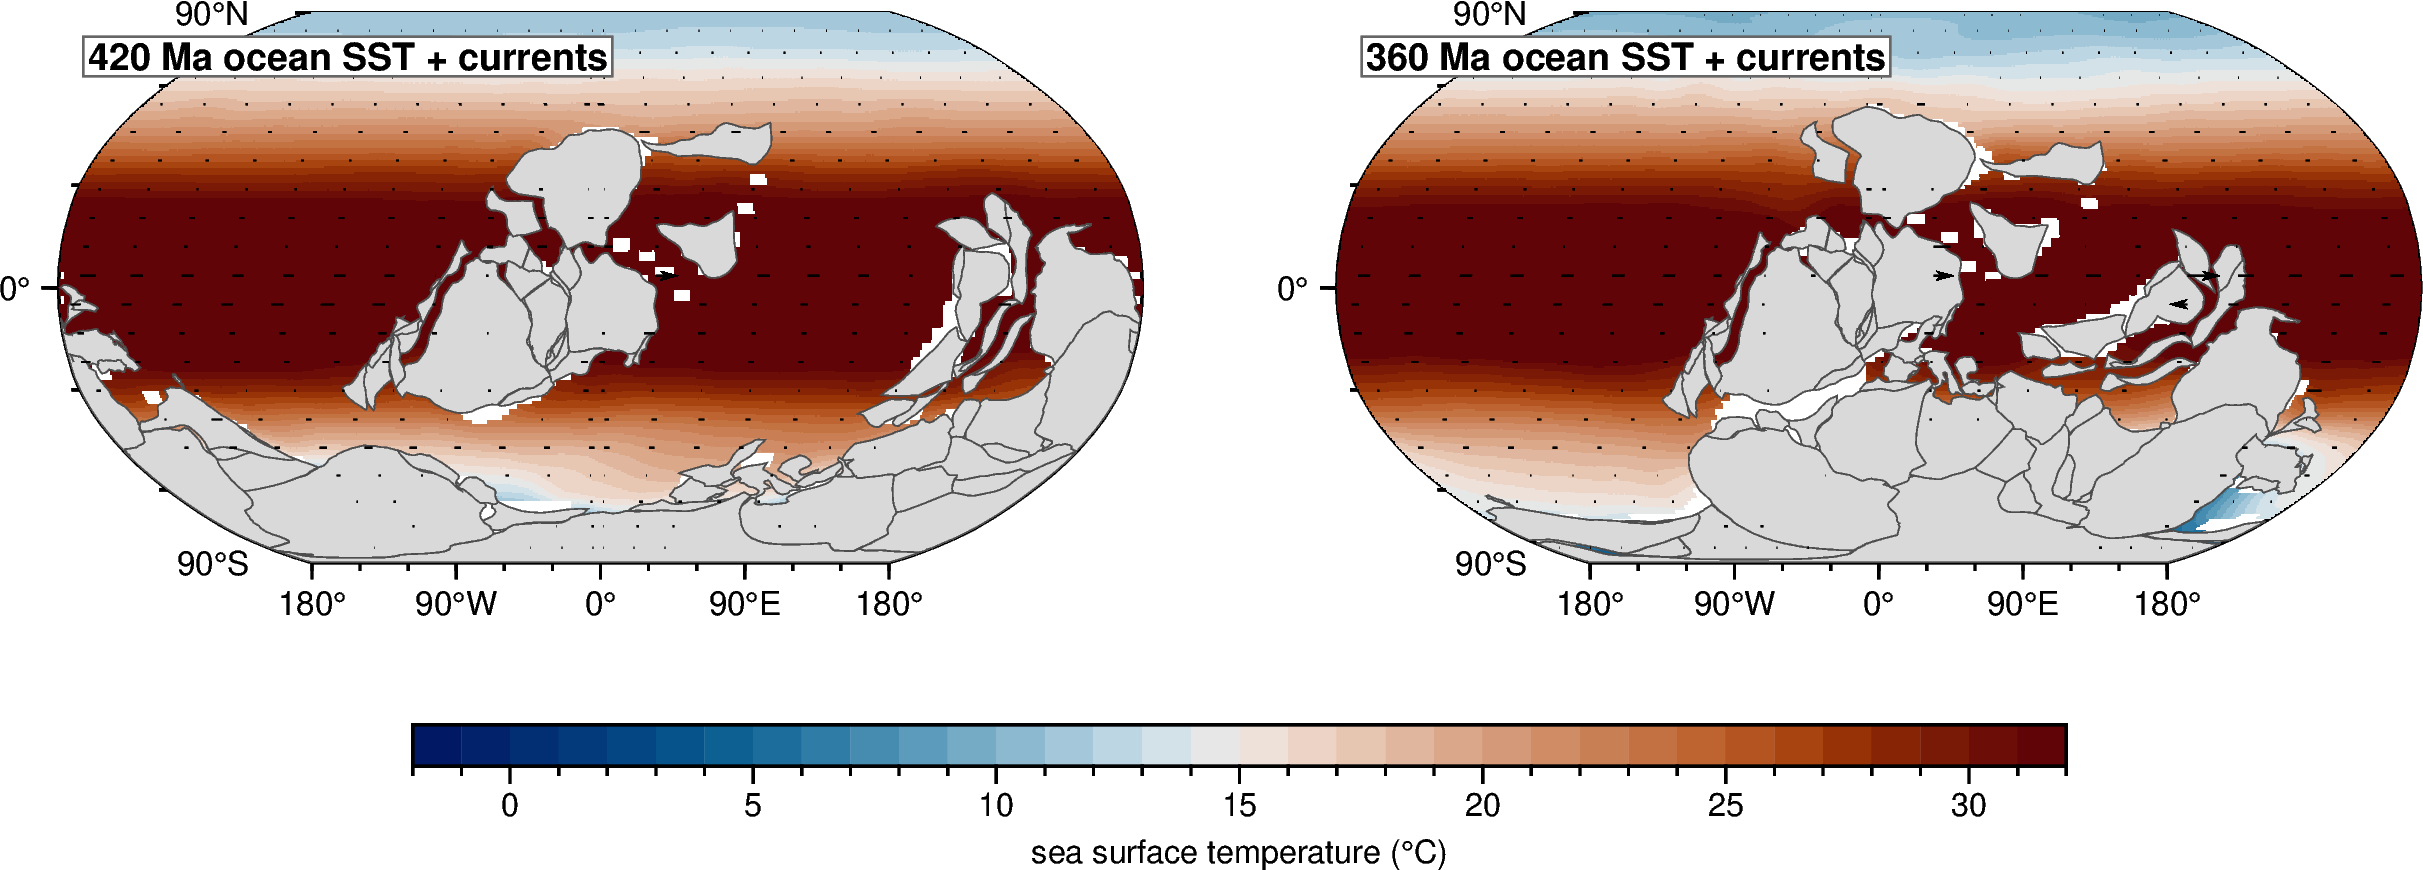

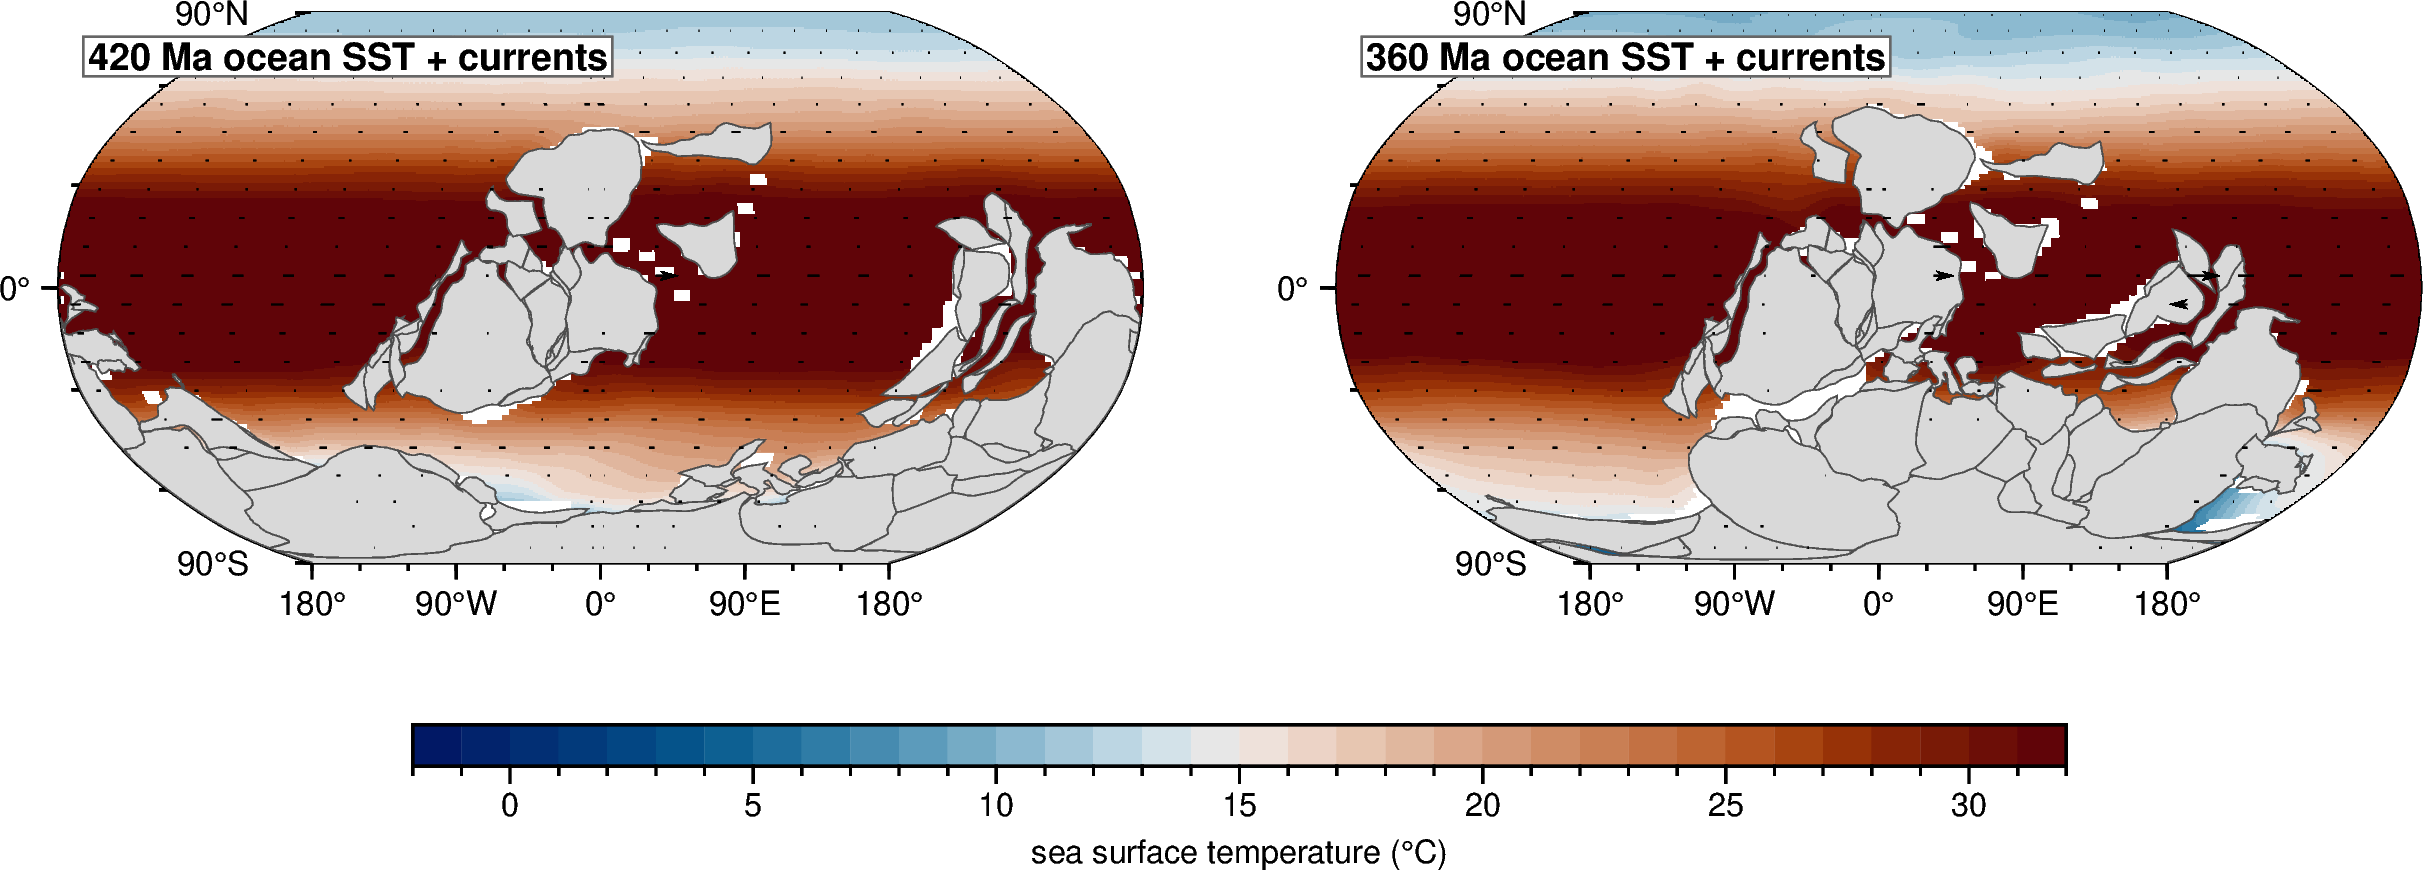

In [6]:
fig = pygmt.Figure()
pygmt.makecpt(cmap="vik", series=[-2, 32, 1], background="o")
with fig.subplot(nrows=1, ncols=2, figsize=("20c", "5.8c"), margins=["0.6c", "0.4c"]):
    for i, age in enumerate(AGES):
        ocean = foam[age]["ocean"]
        sst = ocean["TEMP"].isel(lev=-1).mean(dim="time")
        sst_plot = refine_for_plot(sst.assign_coords(lon=(((ocean.lon + 180) % 360) - 180)).sortby("lon"))
        u = ocean["U"].isel(lev=-1).mean(dim="time")
        v = ocean["V"].isel(lev=-1).mean(dim="time")
        with fig.set_panel(panel=i):
            fig.basemap(region=REGION, projection="N?", frame="af")
            fig.grdimage(grid=sst_plot, nan_transparent=True)
            gm[age].plot_continents(fig, fill="gray85", pen="0.3p,gray30")
            # subsample the current field so arrows are legible rather than a solid mat,
            # and drop land (NaN) cells up front -- GMT would otherwise emit one
            # "Vector magnitude = NaN. Skipped" warning per land grid point.
            step = 6
            lon_g, lat_g = np.meshgrid(ocean.lon.values[::step], ocean.lat.values[::step])
            u_g = u.values[::step, ::step]
            v_g = v.values[::step, ::step]
            finite = np.isfinite(u_g) & np.isfinite(v_g)
            fig.plot(x=lon_g[finite], y=lat_g[finite], style="v0.15c+e",
                      direction=[u_g[finite], v_g[finite]], pen="0.4p,black", fill="black")
            fig.text(text=f"{age:.0f} Ma ocean SST + currents", position="TL",
                      offset="0.25c/-0.25c", justify="TL", font="9p,Helvetica-Bold,black",
                      fill="white", pen="0.5p,gray40")
fig.colorbar(frame="af+lsea surface temperature (\u00b0C)", position="JBC+w14c/0.35c+h+o0/0.8c")
fig.savefig(OUTPUT_DIR / "T69_ocean_sst_currents.png", dpi=150)
fig.show(width=1000)


**What this shows.** Both ages show the expected first-order pattern -- warm low-latitude gyres, cooling poleward -- but the gyre geometry itself differs: the narrower, more equatorial Rheic Ocean gap at 360 Ma constrains low-latitude zonal flow differently than the wider 420 Ma configuration, visibly deflecting the surface current vectors around the converging continents. This is the kind of geometry-driven circulation change Pohl et al. and Gerard et al. argue for -- illustrated directly here with real GCM circulation fields, though this notebook stops at showing the physical climatology and does not attempt to compute an oxygenation or productivity metric, since no open biogeochemical output exists to validate one against (see the notebook's opening scope note).

## 5. Quantifying the 60 Myr change

A direct, honest diagnostic that does not require biogeochemical output: global-mean SST and the equator-to-pole SST contrast at each age, computed straight from the fields already plotted above.

 age_Ma  global_mean_SST  low_lat_SST (<15deg)  high_lat_SST (>60deg)  equator_to_pole_contrast
  420.0            23.30                 35.20                  11.88                     23.32
  360.0            21.75                 34.29                  10.04                     24.24


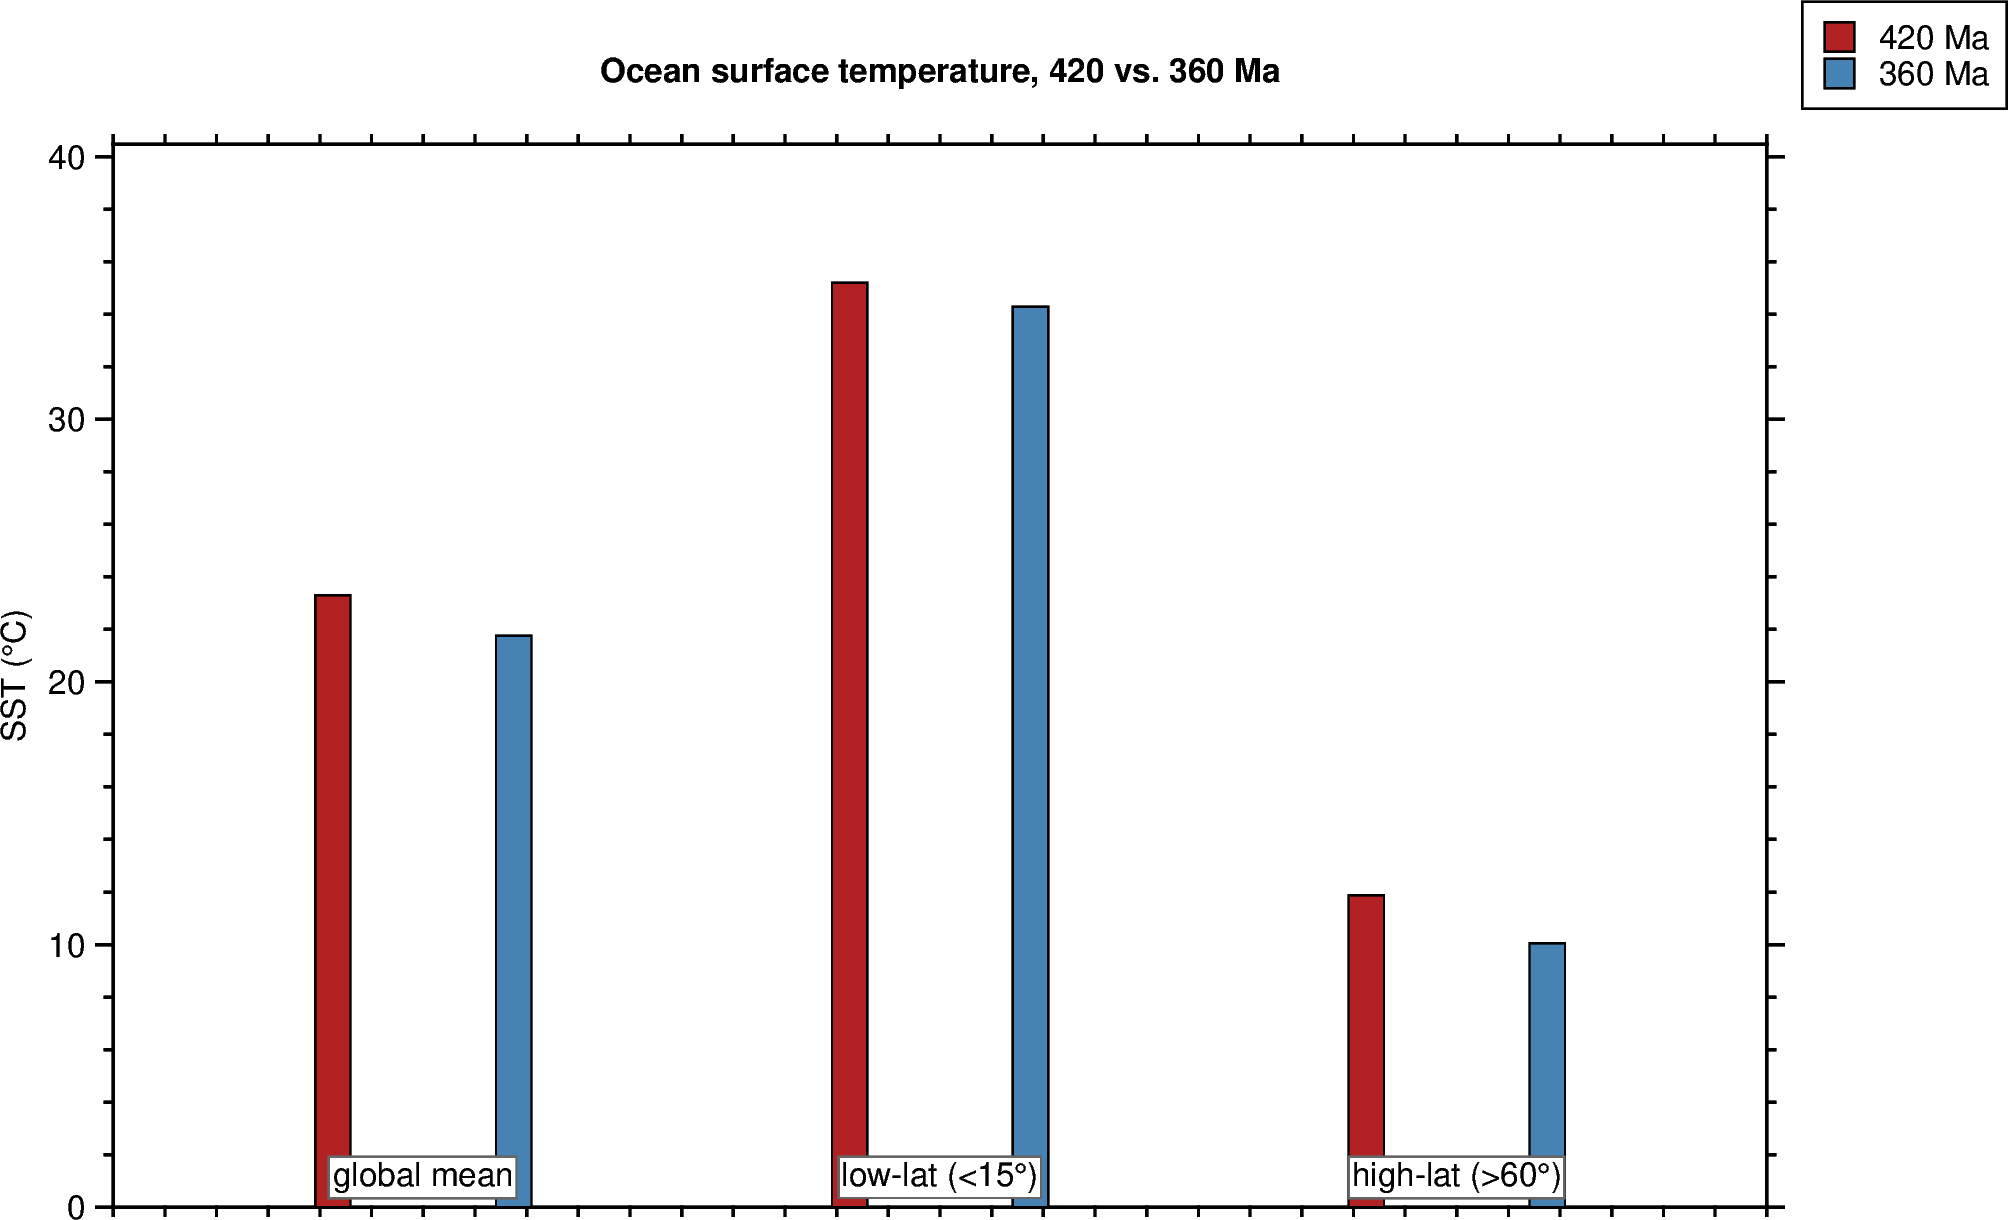

In [7]:
rows = []
for age in AGES:
    ocean = foam[age]["ocean"]
    sst = ocean["TEMP"].isel(lev=-1).mean(dim="time")
    lat = ocean["lat"]
    global_mean = float(sst.mean(skipna=True))
    low_lat = float(sst.where(np.abs(lat) < 15).mean(skipna=True))
    high_lat = float(sst.where(np.abs(lat) > 60).mean(skipna=True))
    rows.append({"age_Ma": age, "global_mean_SST": global_mean, "low_lat_SST (<15deg)": low_lat,
                 "high_lat_SST (>60deg)": high_lat, "equator_to_pole_contrast": low_lat - high_lat})
summary = pd.DataFrame(rows)
print(summary.round(2).to_string(index=False))

fig = pygmt.Figure()
region = [-0.6, 2.6, 0, summary[["global_mean_SST", "low_lat_SST (<15deg)", "high_lat_SST (>60deg)"]].values.max() * 1.15]
fig.basemap(region=region, projection="X14c/9c",
            frame=["WSne+tOcean surface temperature, 420 vs. 360 Ma", "xf", "yaf+lSST (\u00b0C)"])
labels = ["global mean", "low-lat (<15\u00b0)", "high-lat (>60\u00b0)"]
cols = ["global_mean_SST", "low_lat_SST (<15deg)", "high_lat_SST (>60deg)"]
for i, (label, col) in enumerate(zip(labels, cols)):
    for j, age in enumerate(AGES):
        val = summary[summary["age_Ma"] == age][col].values[0]
        fig.plot(x=[i + (j - 0.5) * 0.35], y=[val], style="b0.3c+b0",
                  fill="firebrick" if age == 420.0 else "steelblue", pen="0.5p,black")
    fig.text(x=i, y=region[3] * 0.02, text=label, justify="BC", font="8p",
              fill="white", pen="0.4p,gray40", no_clip=True)
fig.plot(x=[-1], y=[-1], style="s0.35c", fill="firebrick", pen="0.5p,black", label="420 Ma")
fig.plot(x=[-1], y=[-1], style="s0.35c", fill="steelblue", pen="0.5p,black", label="360 Ma")
fig.legend(position="JTR+o0.3c", box="+gwhite+p0.5p")
fig.savefig(OUTPUT_DIR / "T69_sst_comparison.png", dpi=150)
fig.show(width=800)


**What this shows.** All three metrics cool slightly from 420 to 360 Ma in this fixed-CO2 sensitivity-experiment series (as intended -- the point of holding CO2 forcing constant across the `Scot*` series is to isolate the effect of continental configuration alone), but not by equal amounts: the high-latitude mean drops the most in absolute terms (roughly -1.8&deg;C) compared to the global mean (roughly -1.6&deg;C) and the low-latitude mean (roughly -0.9&deg;C), so the equator-to-pole contrast widens slightly overall. That is directionally consistent with the continued northward continental convergence seen in &sect;2's paleogeography panels changing high-latitude land-sea contrast -- but the shifts here are modest (a degree or two), and this notebook is not claiming they explain Pohl et al.'s or Gerard et al.'s own (unarchived) ocean-oxygenation results, which involve biogeochemical processes this physical-climatology comparison cannot reach. Treat this section as a demonstration of how to build such a comparison from real boundary-condition data, not as a replication of the papers' actual finding.

## Extend this

- **Add the intermediate ages.** The FOAM archive covers 0-540 Ma at 20 Myr steps; `380rd_1368W_EccN_*` and `400rd_1368W_EccN_*` (already downloaded alongside 360/420 for this notebook) sit between the two ages shown here and would make a 4-panel time series.
- **Compare against the actual `Scot*` config family's 5 Myr cadence.** The published cGENIE configs step every 5 Myr (`Scot360M`...`Scot420M`); FOAM's own archive is coarser (20 Myr). A finer-resolution atmosphere-ocean climatology, if one becomes available, would let a notebook match the model cadence exactly.
- **If you can run cGENIE yourself**, the actual `Scot360M`-`Scot420M` configs are in `github.com/derpycode/cgenie.muffin`, under `genie-userconfigs/MS/pohletal.Nature.2022/` and `genie-userconfigs/PUBS/published/Gerard_et_al_2024/` -- running even one spin-up would let you compare a real cGENIE-derived O2 field against this notebook's FOAM-derived physical fields directly.
- **Cross-reference T67** (pySCION Phanerozoic biogeochemistry) for a complementary, already-runnable whole-Phanerozoic biogeochemical box model view of the same broad interval.

## Related notebooks

- **T65** -- cGENIE SST vs. proxies (Eocene/PETM). Sibling cGENIE-family notebook, different event, and (unlike this one) uses archived cGENIE *output*.
- **T66** -- End-Permian CO2-sensitivity ensemble (PLASIM-GENIE). Another GENIE-family sensitivity-experiment series, different mass-extinction boundary.
- **T67** -- pySCION Phanerozoic biogeochemistry. Whole-Phanerozoic box-model complement to this notebook's single-interval GCM snapshot.
- **T70** -- PhanSST deep-time SST proxies. Real proxy data (not model output) for a different deep-time interval, same `gplately` reconstruction pattern.

## References

Pohl, A., Ridgwell, A., Stockey, R.G., Thomazo, C., Keane, A., Vennin, E. & Scotese, C.R. (2022). Continental configuration controls ocean oxygenation during the Phanerozoic. *Nature* 608, 523-527. https://doi.org/10.1038/s41586-022-05018-z

G&eacute;rard, J., Sablon, L., Huygh, J.J.C., Da Silva, A.-C., Pohl, A., V&eacute;rard, C. & Crucifix, M. (2025). Exploring the mechanisms of Devonian oceanic anoxia: impact of ocean dynamics, palaeogeography and orbital forcing. *Climate of the Past* 21(1), 239-260. https://doi.org/10.5194/cp-21-239-2025

Pohl, A. -- Phanerozoic global climatic fields simulated using the FOAM ocean-atmosphere general circulation model [Data set]. Zenodo. https://doi.org/10.5281/zenodo.5780097 (CC BY 4.0).

Ridgwell, A., et al. cGENIE.muffin Earth system model. https://github.com/derpycode/cgenie.muffin

Scotese, C.R. & Wright, N. (2018). PALEOMAP Paleodigital Elevation Models (PaleoDEMS) for the Phanerozoic. https://www.earthbyte.org/paleodem-resource-scotese-and-wright-2018/. Archived at https://doi.org/10.5281/zenodo.5460860

Mather, B.R., Muller, R.D., Zahirovic, S., et al. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal* 11, 3-10. https://doi.org/10.1002/gdj3.185
